# **MNIST Binary Classification**

## **Importing Dependencies**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import joblib

In [2]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, average_precision_score, roc_curve, RocCurveDisplay, roc_auc_score

In [3]:
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

## **Data Collection & Exploration**

In [4]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [5]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [6]:
mnist.details

{'id': '554',
 'name': 'mnist_784',
 'version': '1',
 'description_version': '2',
 'format': 'ARFF',
 'creator': ['Yann LeCun', 'Corinna Cortes', 'Christopher J.C. Burges'],
 'upload_date': '2014-09-29T03:28:38',
 'language': 'English',
 'licence': 'Public',
 'url': 'https://openml.org/data/v1/download/52667/mnist_784.arff',
 'parquet_url': 'https://data.openml.org/datasets/0000/0554/dataset_554.pq',
 'file_id': '52667',
 'default_target_attribute': 'class',
 'tag': ['Artificial Intelligence',
  'AzurePilot',
  'Computer Vision',
  'Data Sets',
  'Kaggle',
  'Machine Learning',
  'OpenML-CC18',
  'OpenML100',
  'study_1',
  'study_123',
  'study_41',
  'study_99',
  'vision'],
 'visibility': 'public',
 'status': 'active',
 'processing_date': '2020-11-20 20:12:09',
 'md5_checksum': '0298d579eb1b86163de7723944c7e495'}

In [7]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [8]:
mnist.categories

{'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']}

In [9]:
X = mnist.data
Y = mnist.target

In [10]:
X.shape

(70000, 784)

In [11]:
Y.shape

(70000,)

In [12]:
def plot_digit(image_data):
    image = image_data.reshape(28,28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

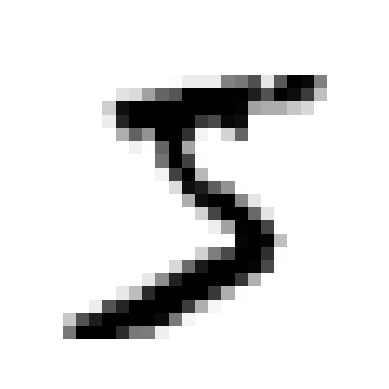

In [13]:
some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [14]:
Y[0]

'5'

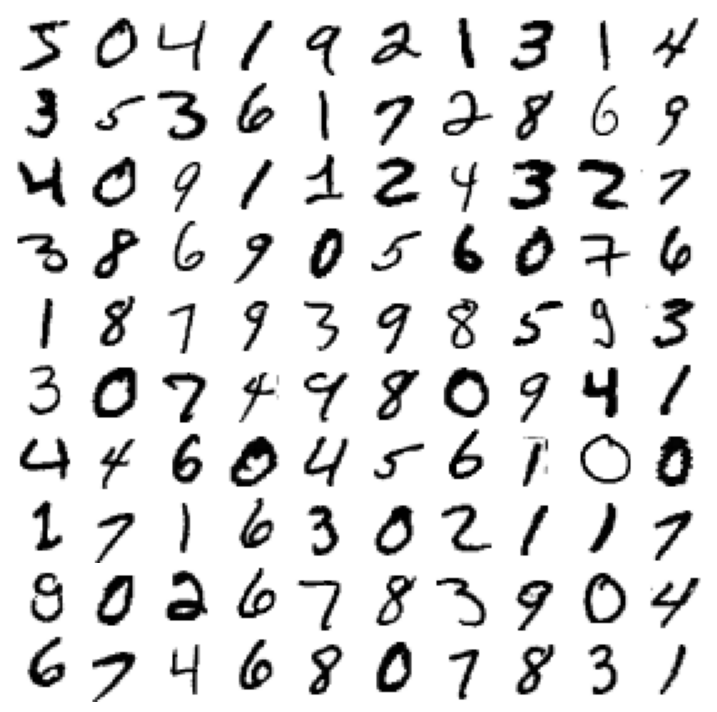

In [15]:
plt.figure(figsize=(9,9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx+1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

## **Data Spliting**

In [16]:
X_train, X_test, Y_train, Y_test = X[:60000], X[60000:], Y[:60000], Y[60000:]

## **Model Training & Evaluation**

#### Detecting 5 or not 5

In [17]:
Y_train_5 = (Y_train == '5')
Y_test_5 = (Y_test == '5')

### **SGD Classifier**

In [18]:
sgd_clf = SGDClassifier(random_state=3, n_jobs=-1)

In [19]:
sgd_clf.fit(X_train, Y_train_5)

SGDClassifier(n_jobs=-1, random_state=3)

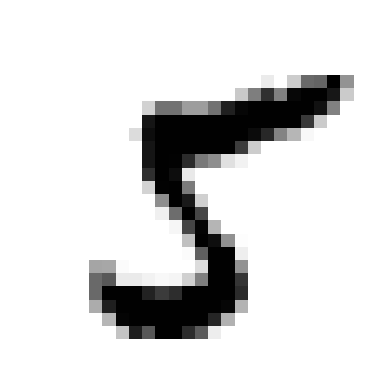

In [20]:
some_digit = X_train[236]
plot_digit(some_digit)
plt.show()

In [21]:
sgd_clf.predict([some_digit])

array([ True])

In [22]:
cross_val_score(sgd_clf, X_train, Y_train_5, cv=3, scoring="accuracy")

array([0.971 , 0.9634, 0.9646])

In [23]:
Y_train_pred = cross_val_predict(sgd_clf, X_train, Y_train_5, cv=3)

In [24]:
accuracy_score(Y_train_5, Y_train_pred)

0.9663333333333334

In [25]:
cm = confusion_matrix(Y_train_5, Y_train_pred)
cm

array([[54029,   550],
       [ 1470,  3951]])

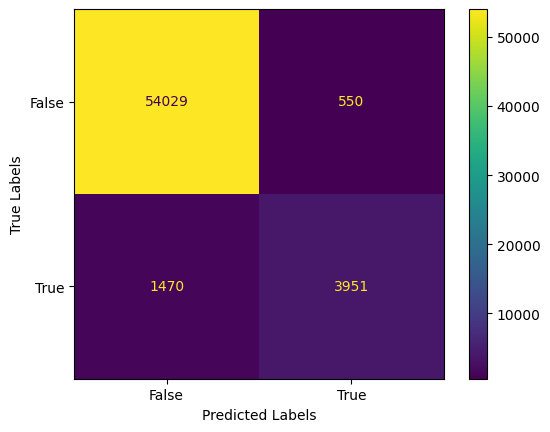

In [26]:
ConfusionMatrixDisplay.from_predictions(Y_train_5, Y_train_pred)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [27]:
precision_score(Y_train_5, Y_train_pred)

0.8778049322372806

In [28]:
recall_score(Y_train_5, Y_train_pred)

0.7288323187603764

In [29]:
f1_score(Y_train_5, Y_train_pred)

0.796412013706914

In [30]:
print(classification_report(Y_train_5, Y_train_pred))

              precision    recall  f1-score   support

       False       0.97      0.99      0.98     54579
        True       0.88      0.73      0.80      5421

    accuracy                           0.97     60000
   macro avg       0.93      0.86      0.89     60000
weighted avg       0.96      0.97      0.96     60000



In [31]:
Y_score = sgd_clf.decision_function([some_digit])
Y_score

array([178.84539059])

In [32]:
threshold = 0
Y_some_digit_pred = (Y_score > threshold)
Y_some_digit_pred

array([ True])

In [33]:
threshold = 500
Y_some_digit_pred = (Y_score > threshold)
Y_some_digit_pred

array([False])

In [34]:
Y_scores = cross_val_predict(sgd_clf, X_train, Y_train_5, method="decision_function", cv=3)

In [35]:
precisions, recalls, thresholds = precision_recall_curve(Y_train_5, Y_scores)

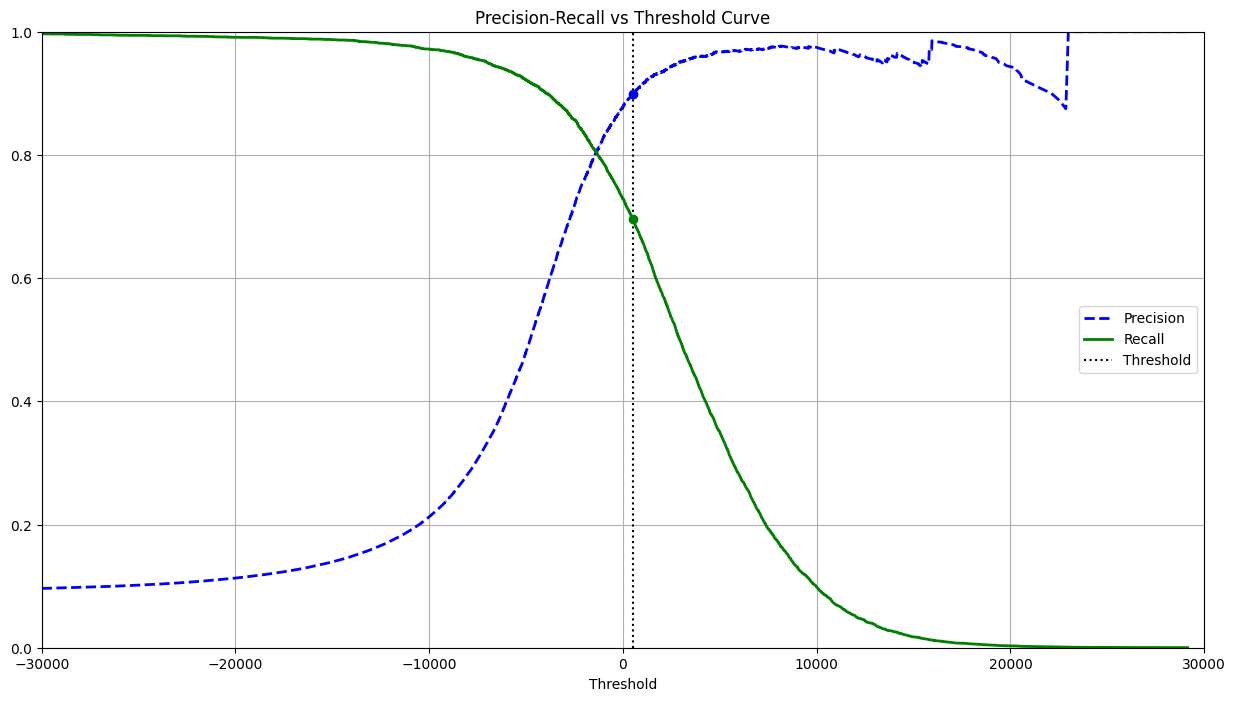

In [36]:
plt.figure(figsize=(15,8))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="Threshold")
idx = (thresholds > threshold).argmax()
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-30000, 30000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
plt.title("Precision-Recall vs Threshold Curve")
plt.show()

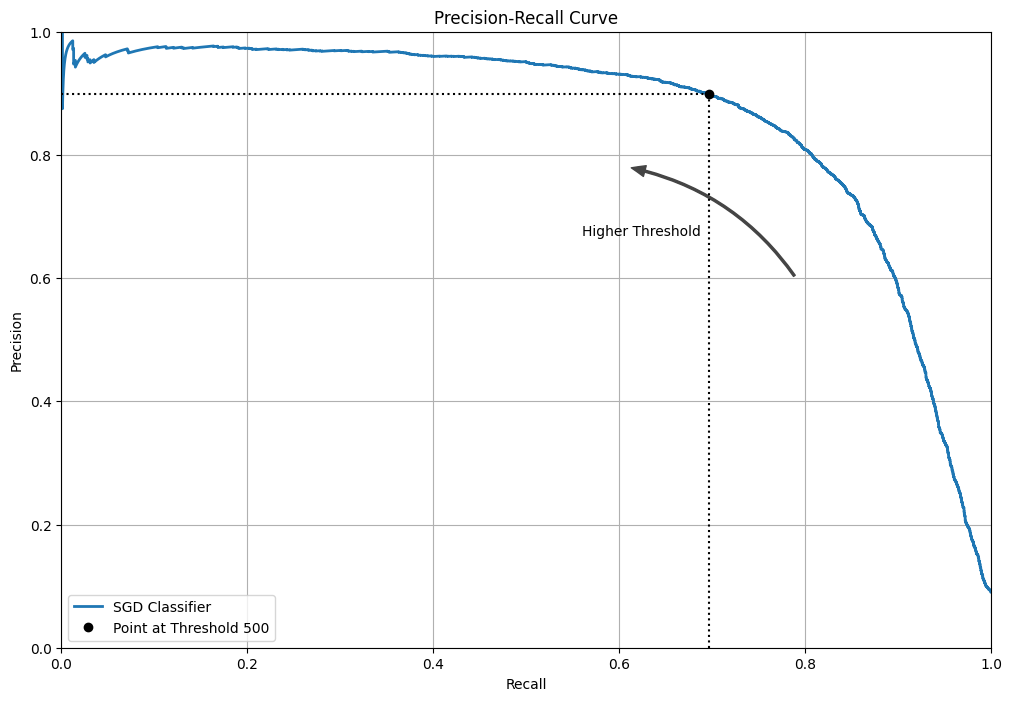

In [37]:
plt.figure(figsize=(12,8))
plt.plot(recalls, precisions, label="SGD Classifier", linewidth=2)
idx = (thresholds > threshold).argmax()
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko", label=f"Point at Threshold {threshold}")

plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.6), (0.61, 0.78), connectionstyle="arc3,rad=.2", arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10", color="#444444"))
plt.text(0.56, 0.67, "Higher Threshold")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0,1,0,1])
plt.grid()
plt.legend(loc="lower left")
plt.title("Precision-Recall Curve")
plt.show()

In [38]:
average_precision_score(Y_train_5, Y_scores) # Area under PR Curves

np.float64(0.8600695922844536)

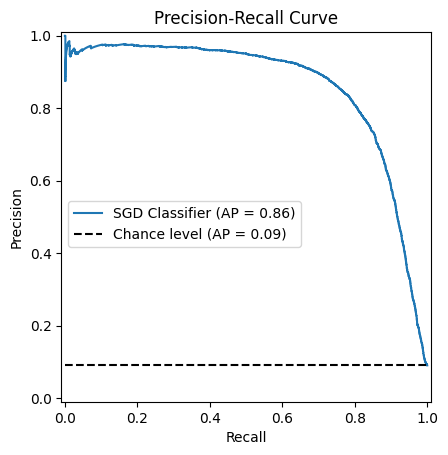

In [39]:
display = PrecisionRecallDisplay.from_predictions(Y_train_5, Y_scores, name="SGD Classifier", plot_chance_level=True)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left", bbox_to_anchor=(0, 0.4)) 
plt.title("Precision-Recall Curve")
plt.show()

In [40]:
idx_for_90_precision = (precisions >= 0.9).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(548.9551779696664)

In [41]:
Y_train_pred_90 = (Y_scores >= threshold_for_90_precision)

In [42]:
precision_score(Y_train_5, Y_train_pred_90)

0.9001914791766396

In [43]:
recall_at_90_precision = recall_score(Y_train_5, Y_train_pred_90)
recall_at_90_precision

0.693783434790629

In [44]:
fpr, tpr, thresholds = roc_curve(Y_train_5, Y_scores)

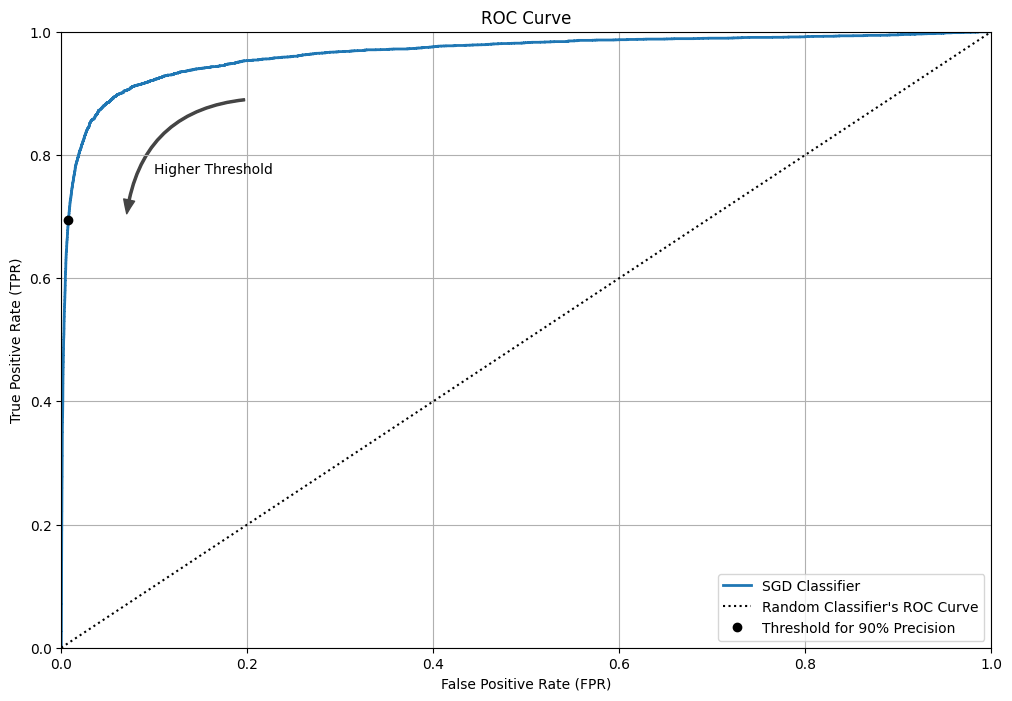

In [45]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
fpr_90, tpr_90 = fpr[idx_for_threshold_at_90], tpr[idx_for_threshold_at_90] 

plt.figure(figsize=(12,8))
plt.plot(fpr, tpr, label="SGD Classifier", linewidth=2)
plt.plot([0, 1], [0, 1], "k:", label="Random Classifier's ROC Curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% Precision")

plt.gca().add_patch(patches.FancyArrowPatch(
    (0.2, 0.89), (0.07, 0.7), connectionstyle="arc3,rad=.4", arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10", color="#444444"))
plt.text(0.10, 0.77, "Higher Threshold")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.axis([0,1,0,1])
plt.grid()
plt.legend(loc="lower right")
plt.title("ROC Curve")
plt.show()

In [46]:
roc_auc_score(Y_train_5, Y_scores)

np.float64(0.9648958388899872)

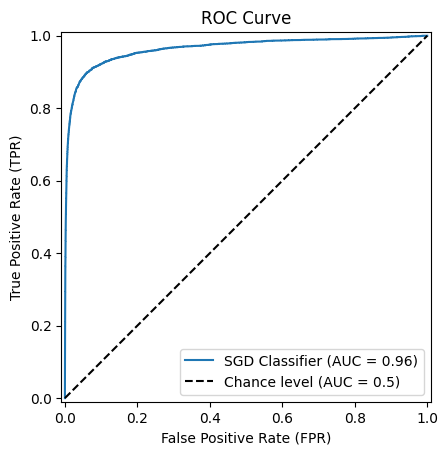

In [47]:
display = RocCurveDisplay.from_predictions(Y_train_5, Y_scores, name="SGD Classifier", plot_chance_level=True)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend(loc="lower right") 
plt.title("ROC Curve")
plt.show()

### **Support Vector Machine (SVM) - RBF Kernel**  

In [48]:
svm_clf = SVC(kernel='rbf', random_state=3)

In [49]:
Y_scores_svm = cross_val_predict(svm_clf, X_train, Y_train_5, cv=3, method="decision_function")

In [50]:
precisions_svm, recalls_svm, thresholds_svm = precision_recall_curve(Y_train_5, Y_scores_svm)

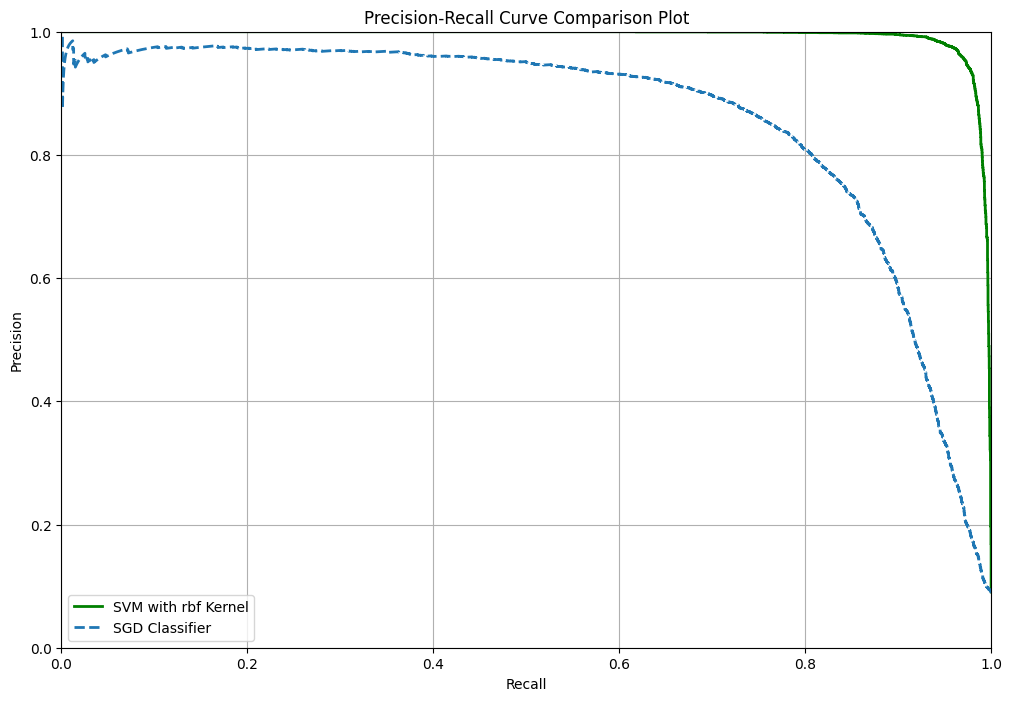

In [51]:
plt.figure(figsize=(12,8))
plt.plot(recalls_svm, precisions_svm,"g-", label="SVM with rbf Kernel", linewidth=2)
plt.plot(recalls, precisions,"--", label="SGD Classifier", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0,1,0,1])
plt.grid()
plt.legend(loc="lower left")
plt.title("Precision-Recall Curve Comparison Plot")
plt.show()

In [52]:
average_precision_score(Y_train_5, Y_scores_svm)

np.float64(0.992828821826264)

In [53]:
fpr_svm, tpr_svm, thresholds_svms = roc_curve(Y_train_5, Y_scores_svm)

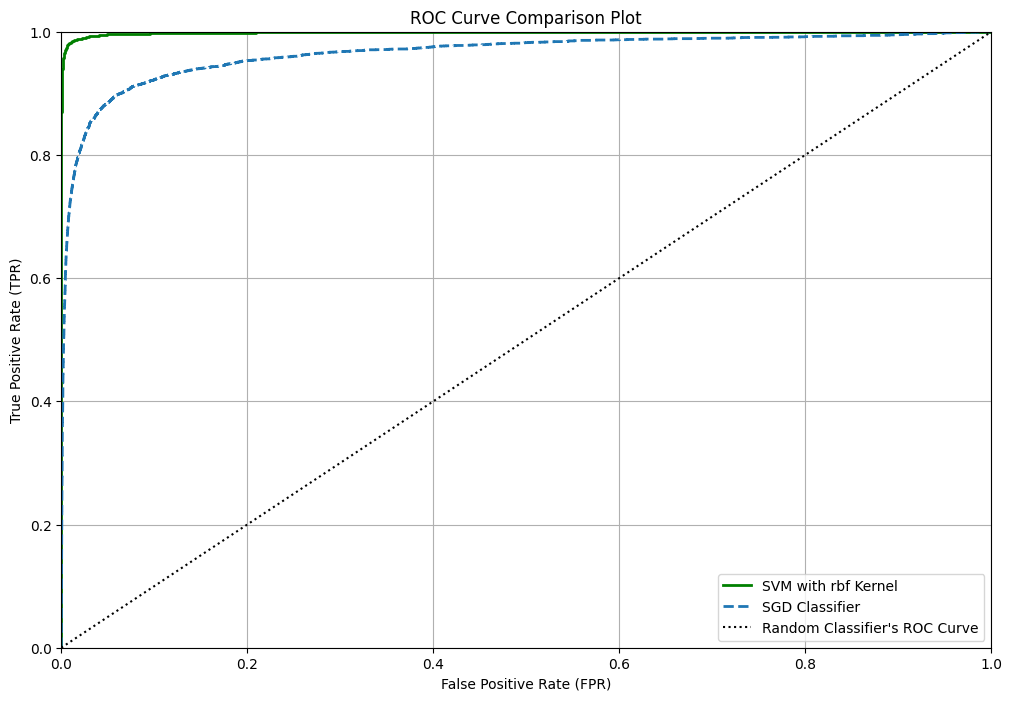

In [54]:
plt.figure(figsize=(12,8))
plt.plot(fpr_svm, tpr_svm,"g-", label="SVM with rbf Kernel", linewidth=2)
plt.plot(fpr, tpr,"--", label="SGD Classifier", linewidth=2)
plt.plot([0, 1], [0, 1], "k:", label="Random Classifier's ROC Curve")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.axis([0,1,0,1])
plt.grid()
plt.legend(loc="lower right")
plt.title("ROC Curve Comparison Plot")
plt.show()

In [55]:
roc_auc_score(Y_train_5, Y_scores_svm)

np.float64(0.9986234183864152)

In [56]:
Y_train_pred_svm = (Y_scores_svm > 0)

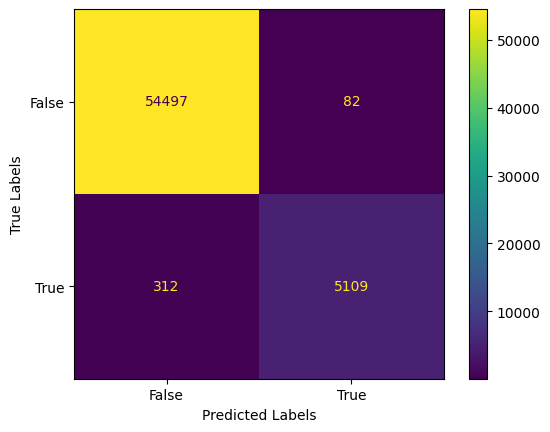

In [57]:
ConfusionMatrixDisplay.from_predictions(Y_train_5, Y_train_pred_svm)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [58]:
print("Accuracy =", accuracy_score(Y_train_5, Y_train_pred_svm))
print("Precision =", precision_score(Y_train_5, Y_train_pred_svm))
print("Recall =", recall_score(Y_train_5, Y_train_pred_svm))
print("F1 Score =", f1_score(Y_train_5, Y_train_pred_svm))

Accuracy = 0.9934333333333333
Precision = 0.9842034290117511
Recall = 0.9424460431654677
F1 Score = 0.9628722201281568


In [59]:
print(classification_report(Y_train_5, Y_train_pred_svm))

              precision    recall  f1-score   support

       False       0.99      1.00      1.00     54579
        True       0.98      0.94      0.96      5421

    accuracy                           0.99     60000
   macro avg       0.99      0.97      0.98     60000
weighted avg       0.99      0.99      0.99     60000



### **Random Forest Classifier** 

In [60]:
forest_clf = RandomForestClassifier(n_jobs=-1, random_state=3)

In [61]:
Y_probas_forest = cross_val_predict(forest_clf, X_train, Y_train_5, cv=3, method="predict_proba")

In [62]:
Y_probas_forest[:2]

array([[0.09, 0.91],
       [0.98, 0.02]])

In [63]:
Y_scores_forest = Y_probas_forest[:,1]

In [64]:
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(Y_train_5, Y_scores_forest)

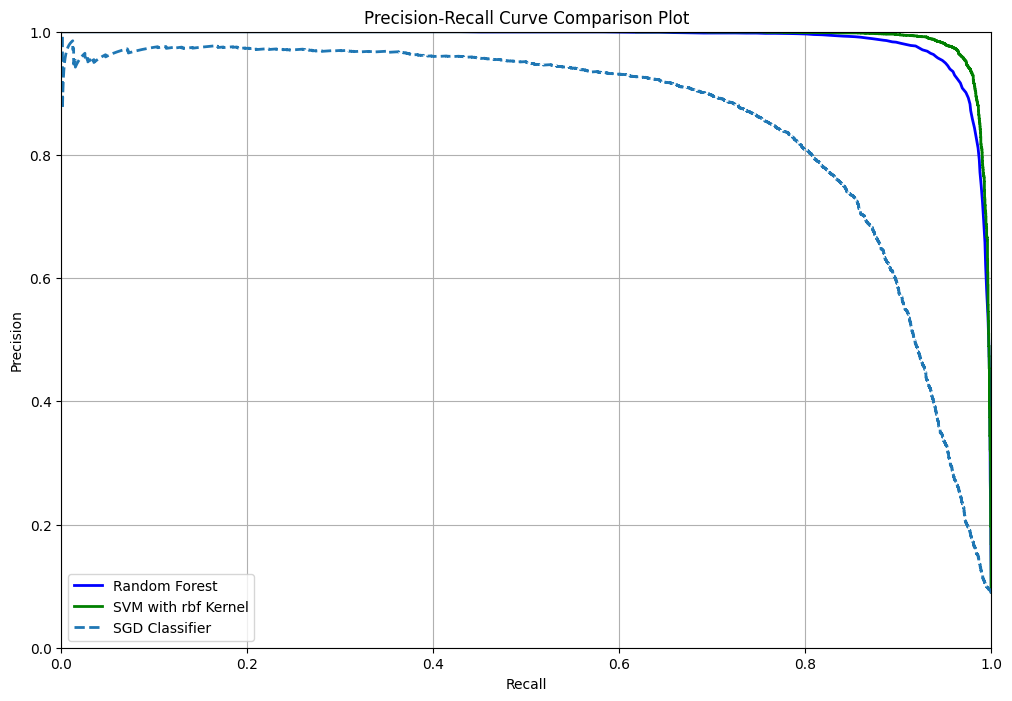

In [65]:
plt.figure(figsize=(12,8))
plt.plot(recalls_forest, precisions_forest,"b-", label="Random Forest", linewidth=2)
plt.plot(recalls_svm, precisions_svm,"g-", label="SVM with rbf Kernel", linewidth=2)
plt.plot(recalls, precisions,"--", label="SGD Classifier", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0,1,0,1])
plt.grid()
plt.legend(loc="lower left")
plt.title("Precision-Recall Curve Comparison Plot")
plt.show()

In [66]:
average_precision_score(Y_train_5, Y_scores_forest)

np.float64(0.9876773432268825)

In [67]:
fpr_forest, tpr_forest, thresholds_forests = roc_curve(Y_train_5, Y_scores_forest)

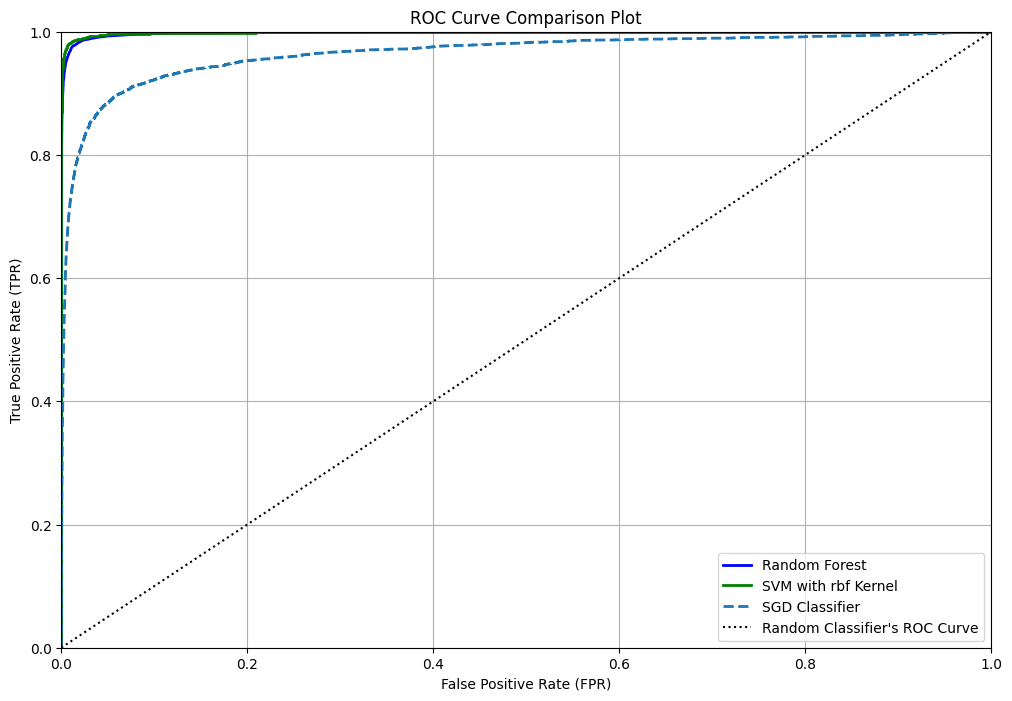

In [68]:
plt.figure(figsize=(12,8))
plt.plot(fpr_forest, tpr_forest,"b-", label="Random Forest", linewidth=2)
plt.plot(fpr_svm, tpr_svm,"g-", label="SVM with rbf Kernel", linewidth=2)
plt.plot(fpr, tpr,"--", label="SGD Classifier", linewidth=2)
plt.plot([0, 1], [0, 1], "k:", label="Random Classifier's ROC Curve")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.axis([0,1,0,1])
plt.grid()
plt.legend(loc="lower right")
plt.title("ROC Curve Comparison Plot")
plt.show()

In [69]:
roc_auc_score(Y_train_5, Y_scores_forest)

np.float64(0.998034538556488)

In [70]:
Y_train_pred_forest = (Y_scores_forest >= 0.5)

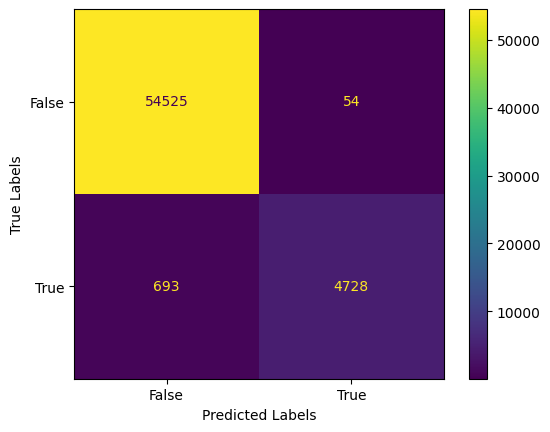

In [71]:
ConfusionMatrixDisplay.from_predictions(Y_train_5, Y_train_pred_forest)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [72]:
print("Accuracy =", accuracy_score(Y_train_5, Y_train_pred_forest))
print("Precision =", precision_score(Y_train_5, Y_train_pred_forest))
print("Recall =", recall_score(Y_train_5, Y_train_pred_forest))
print("F1 Score =", f1_score(Y_train_5, Y_train_pred_forest))

Accuracy = 0.98755
Precision = 0.9887076537013801
Recall = 0.872163807415606
F1 Score = 0.9267862393413702


In [73]:
print(classification_report(Y_train_5, Y_train_pred_forest))

              precision    recall  f1-score   support

       False       0.99      1.00      0.99     54579
        True       0.99      0.87      0.93      5421

    accuracy                           0.99     60000
   macro avg       0.99      0.94      0.96     60000
weighted avg       0.99      0.99      0.99     60000



## **Final Model Selection & Evaluation** 

In [74]:
final_model = svm_clf

In [75]:
final_model.fit(X_train, Y_train_5)

SVC(random_state=3)

In [76]:
hasattr(final_model, 'predict_proba')

False

In [77]:
hasattr(final_model, 'decision_function')

True

In [78]:
Y_test_scores = final_model.decision_function(X_test)

In [79]:
Y_test_pred = (Y_test_scores > 0)

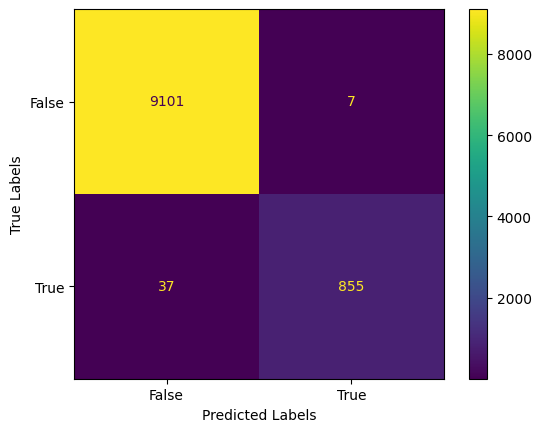

In [80]:
ConfusionMatrixDisplay.from_predictions(Y_test_5, Y_test_pred)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [81]:
print("Accuracy =", accuracy_score(Y_test_5, Y_test_pred))
print("Precision =", precision_score(Y_test_5, Y_test_pred))
print("Recall =", recall_score(Y_test_5, Y_test_pred))
print("F1 Score =", f1_score(Y_test_5, Y_test_pred))

Accuracy = 0.9956
Precision = 0.9918793503480279
Recall = 0.9585201793721974
F1 Score = 0.9749144811858609


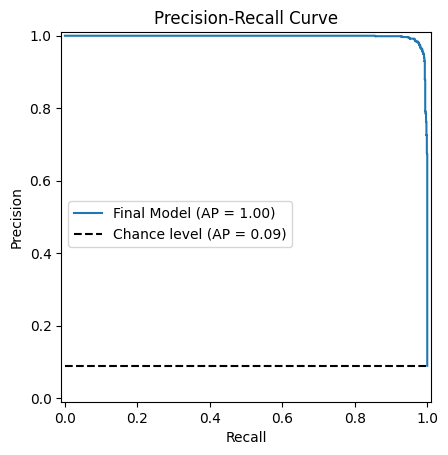

In [82]:
# If used .predict() function instead and avoided raw Y_test_scores calculation
# display = PrecisionRecallDisplay.from_estimator(final_model, X_test, Y_test_5, name="Final Model", plot_chance_level=True)

display = PrecisionRecallDisplay.from_predictions(Y_test_5, Y_test_scores, name="Final Model", plot_chance_level=True)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left", bbox_to_anchor=(0, 0.4)) 
plt.title("Precision-Recall Curve")
plt.show()

In [83]:
average_precision_score(Y_test_5, Y_test_scores)

np.float64(0.9973315250158236)

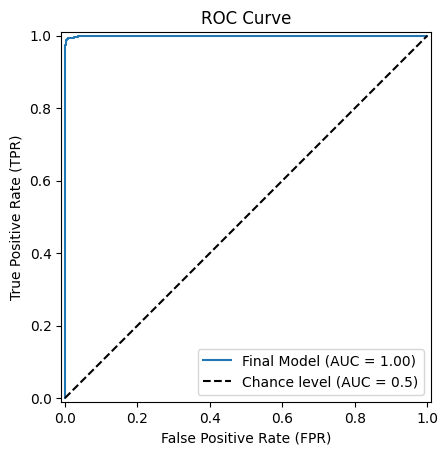

In [84]:
# If used .predict() function instead and avoided raw Y_test_scores calculation
# display = RocCurveDisplay.from_estimator(final_model, X_test, Y_test_5, name="Final Model", plot_chance_level=True)

display = RocCurveDisplay.from_predictions(Y_test_5, Y_test_scores, name="Final Model", plot_chance_level=True)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend(loc="lower right") 
plt.title("ROC Curve")
plt.show()

In [85]:
roc_auc_score(Y_test_5, Y_test_scores)

np.float64(0.9996879745003161)

In [86]:
print(classification_report(Y_test_5, Y_test_pred))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00      9108
        True       0.99      0.96      0.97       892

    accuracy                           1.00     10000
   macro avg       0.99      0.98      0.99     10000
weighted avg       1.00      1.00      1.00     10000



In [87]:
joblib.dump(final_model, "mnist_binary_svm_rbf.pkl", compress=3)
print("Success!!")

Success!!
